# Estonian Football Object Detection

Welcome to the Estonian football object detection competition.

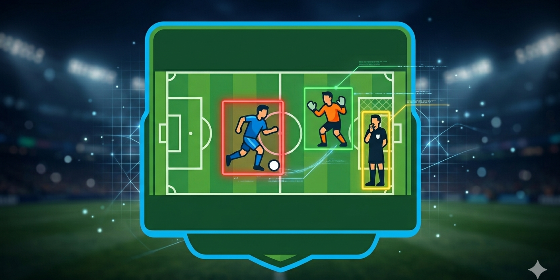

In [ ]:
# Log into Kaggle
import os
os.environ["KAGGLE_API_TOKEN"] = "KGAT_..."

In [ ]:
# Download dataset
!kaggle competitions download -c estonian-football-object-detection

100% 177M/177M [00:02<00:00, 71.2MB/s]



In [ ]:
# Extract data
!unzip -q /content/estonian-football-object-detection.zip

## Dataset

In [ ]:
# Check data was successfully extracted
!ls /content

estonian-football-object-detection.zip	sample_submission.csv  train
sample_data				test


In [ ]:
import os
n_annotations = len(os.listdir("/content/train/annotations"))
n_images = len(os.listdir("/content/train/annotations"))

print(f"Training data contains {n_annotations} annotations and {n_images} images")

Training data contains 574 annotations and 574 images


In [ ]:
n_test = len(os.listdir("/content/test"))
print(f"Test data contains {n_test} images")

Test data contains 150 images


In [ ]:
# Annotations are in Pascal VOC XML format, you can parse them with the
# following code:
def parse_annotation(annt):
    import xml.etree.ElementTree as ET
    annotations = []
    for o in ET.parse(annt).iter("object"):
        class_name = o.find("name").text
        xmin = int(o.find("bndbox").find("xmin").text)
        xmax = int(o.find("bndbox").find("xmax").text)
        ymin = int(o.find("bndbox").find("ymin").text)
        ymax = int(o.find("bndbox").find("ymax").text)
        annotations.append((class_name, xmin, ymin, xmax, ymax))
    return annotations

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Define a function for visualizing an image, given the annotations
def visualize_image(image, annotations):
    class_colors = {
        "Player": "red",
        "Referee": "blue",
        "Goalkeeper": "green"
    }

    ax = plt.gca()
    plt.imshow(image)

    legend_handles = []
    legend_labels = []
    added_classes_to_legend = set()

    for class_name, xmin, ymin, xmax, ymax in annotations:
        color = class_colors[class_name]
        rect = patches.Rectangle(
            (xmin, ymin),
            xmax - xmin,
            ymax - ymin,
            linewidth=1,
            edgecolor=color,
            facecolor="none"
        )
        ax.add_patch(rect)

        if class_name not in added_classes_to_legend:
            legend_handles.append(patches.Patch(color=color, label=class_name))
            legend_labels.append(class_name)
            added_classes_to_legend.add(class_name)

    ax.legend(handles=legend_handles, labels=legend_labels)

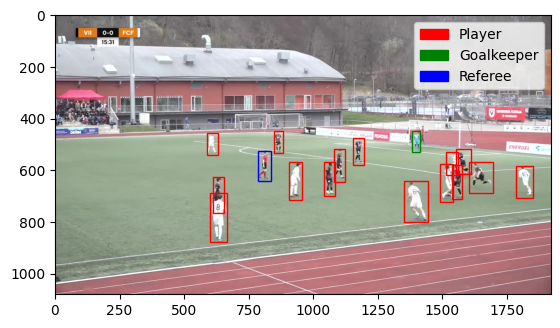

In [ ]:
# Let's visualize one image from the training data

from PIL import Image

annotation_path = "/content/train/annotations/0433_Pi_jr8kBy4g_shot1.xml"
image_path = "/content/train/images/0433_Pi_jr8kBy4g_shot1.jpg"
annotations = parse_annotation(annotation_path)
image = Image.open(image_path)
visualize_image(image, annotations)

Like the image shown above, all training and test examples contain a variable number of goalkeepers, players, and referees on football pitches. In all images, there is at least one such object.

Your goal is to train a object detection model to accurately identify them.

You can read more about the dataset in the [dataset report](https://docs.google.com/document/d/15zuUXqtMJ94OqKPlG-oOlu9TNs3UocBJmyV7f-n87sE/edit?usp=sharing).

## Submission

Once you have trained a model, you have to generate annotations for all 150 images in the test set. 50 of these images will be used to calculate a public score which you can see immediately, and 100 of these which will be used to calculate private score that is used for final evaluation.

The submission file is a CSV file consisting of image name and a set of predictions. The predictions are represented as a string that consists of five element tuples (class, x1, y1, x2, y2) where (x1, y1) is first corner of the predicted bounding box and (x2, y2) is the second corner of the predicted bounding box. In other words, the coordinates are given in same format as they
are given for training samples (xmin, ymin, xmax, ymax).

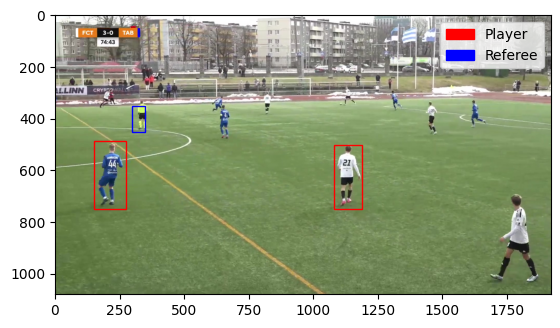

In [ ]:
# Imagine your model generated a prediction like this for 0227_mFa2SgdOvbA_shot3.jpg
predictions = [
    ("Player", 1080, 500, 1190, 750),
    ("Referee", 300, 350, 350, 450),
    ("Player", 150, 485, 275, 750)
]

# Let's first visualize the model's prediction
image = Image.open("/content/test/0227_mFa2SgdOvbA_shot3.jpg")
visualize_image(image, predictions)


In [ ]:
# Let's now generate a valid submission.csv file
import csv

with open("submission.csv", "w") as f:
    writer = csv.writer(f)
    writer.writerow(["image_name", "predictions"])

    # Encode predictions as a string
    prediction_as_string = " ".join([f"{class_name} {x1} {y1} {x2} {y2}" for class_name, x1, y1, x2, y2 in predictions])
    writer.writerow(["0227_mFa2SgdOvbA_shot3.jpg", prediction_as_string])

    # Kaggle requires you to submit predictions for all images in test set.
    # For other images, for now let's generate prediction that all images contain
    # a goalkeeper at a specific position on the pitch
    for file in os.listdir("/content/test"):
      if file != "0227_mFa2SgdOvbA_shot3.jpg":
        writer.writerow([file, "Goalkeeper 350 260 420 460"])

In [ ]:
# Upload the submission to kaggle
!kaggle competitions submit -c estonian-football-object-detection -f submission.csv -m 'my fancy model'

100% 8.12k/8.12k [00:00<00:00, 11.8kB/s]
Successfully submitted to Estonian Football Object Detection

##  Good luck!